C:\Temp\ipykernel_35504\3877024957.py:4: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(image, cmap = 'gray')
c:\Users\Shivraj Sarode\anaconda3\envs\Phelma\Lib\site-packages\skimage\io\_plugins\matplotlib_plugin.py:158: UserWarning: Low image data range; displaying image with stretched contrast.
  lo, hi, cmap = _get_display_range(image)


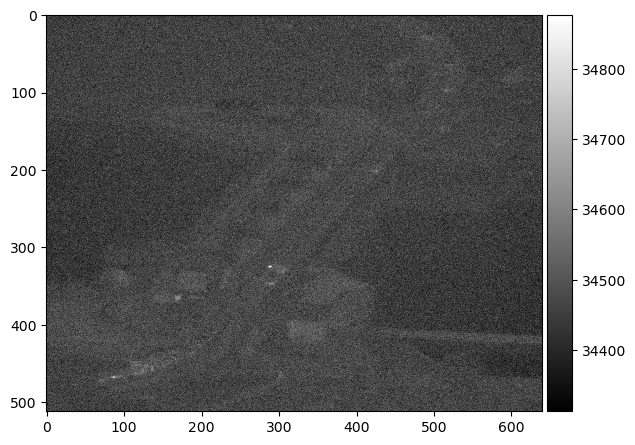

In [71]:
from skimage import io
import numpy as np
image=io.imread(r"C:\Users\Shivraj Sarode\Desktop\DC_Pics\train\VGA\sequence_1\low dyn with columns 1\result\frame_0100.png")
io.imshow(image, cmap = 'gray')

#### Normalisation min-max simple : image_8bit = (image_16bit - min) / (max - min) * 255

C:\Temp\ipykernel_35504\881963002.py:8: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(img_final)


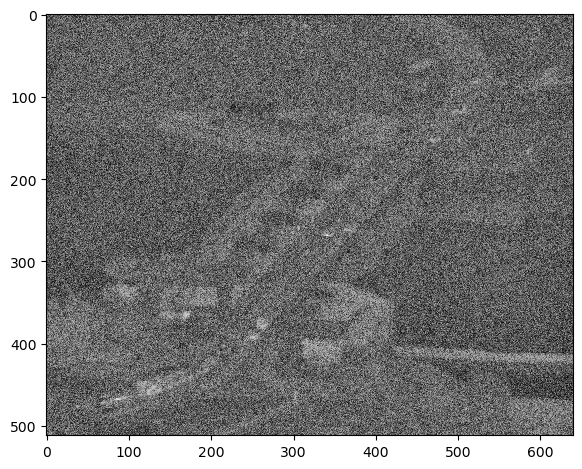

In [3]:
import cv2
import numpy as np

# Conversion nécessaire pour CLAHE (qui travaille en 8 bits)
img_8bit = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
img_final = clahe.apply(img_8bit)
io.imshow(img_final)

## To ckeck if the defect column width is one pixel wide or more

In [44]:
import cv2
import numpy as np

# Load as 16-bit (UNCHANGED)
img = cv2.imread(r"C:\Users\Shivraj Sarode\Desktop\DC_Pics\train\VGA\sequence_1\low dyn with columns 1\frame_0000.png")
# print (img)

# Pick a row in the middle (e.g., row 100)
# Let's look at the area around column 150 (change this to your suspect column)
suspect_col = 450 
row_data = img[300, suspect_col-10 : suspect_col+10]
l = 0
defect_column = 468
defect = []
for l in range (512):
    defect.append((l,defect_column))
# print(f"Values around column {suspect_col}:")
print(row_data)
list_of_rows = []
print (defect[0])
for l in defect:
    list_of_rows.append(l[0])
print (list_of_rows)



[[130 130 130]
 [130 130 130]
 [130 130 130]
 [129 129 129]
 [129 129 129]
 [129 129 129]
 [129 129 129]
 [130 130 130]
 [130 130 130]
 [130 130 130]
 [129 129 129]
 [129 129 129]
 [129 129 129]
 [129 129 129]
 [130 130 130]
 [130 130 130]
 [129 129 129]
 [129 129 129]
 [129 129 129]
 [129 129 129]]
(0, 468)
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159,

Now we know that for this image there is a defect on column 468. 

## For defect correction using mean

[(0, 468), (1, 468), (2, 468), (3, 468), (4, 468), (5, 468), (6, 468), (7, 468), (8, 468), (9, 468), (10, 468), (11, 468), (12, 468), (13, 468), (14, 468), (15, 468), (16, 468), (17, 468), (18, 468), (19, 468), (20, 468), (21, 468), (22, 468), (23, 468), (24, 468), (25, 468), (26, 468), (27, 468), (28, 468), (29, 468), (30, 468), (31, 468), (32, 468), (33, 468), (34, 468), (35, 468), (36, 468), (37, 468), (38, 468), (39, 468), (40, 468), (41, 468), (42, 468), (43, 468), (44, 468), (45, 468), (46, 468), (47, 468), (48, 468), (49, 468), (50, 468), (51, 468), (52, 468), (53, 468), (54, 468), (55, 468), (56, 468), (57, 468), (58, 468), (59, 468), (60, 468), (61, 468), (62, 468), (63, 468), (64, 468), (65, 468), (66, 468), (67, 468), (68, 468), (69, 468), (70, 468), (71, 468), (72, 468), (73, 468), (74, 468), (75, 468), (76, 468), (77, 468), (78, 468), (79, 468), (80, 468), (81, 468), (82, 468), (83, 468), (84, 468), (85, 468), (86, 468), (87, 468), (88, 468), (89, 468), (90, 468), (91, 468

(np.float64(-0.5), np.float64(639.5), np.float64(511.5), np.float64(-0.5))

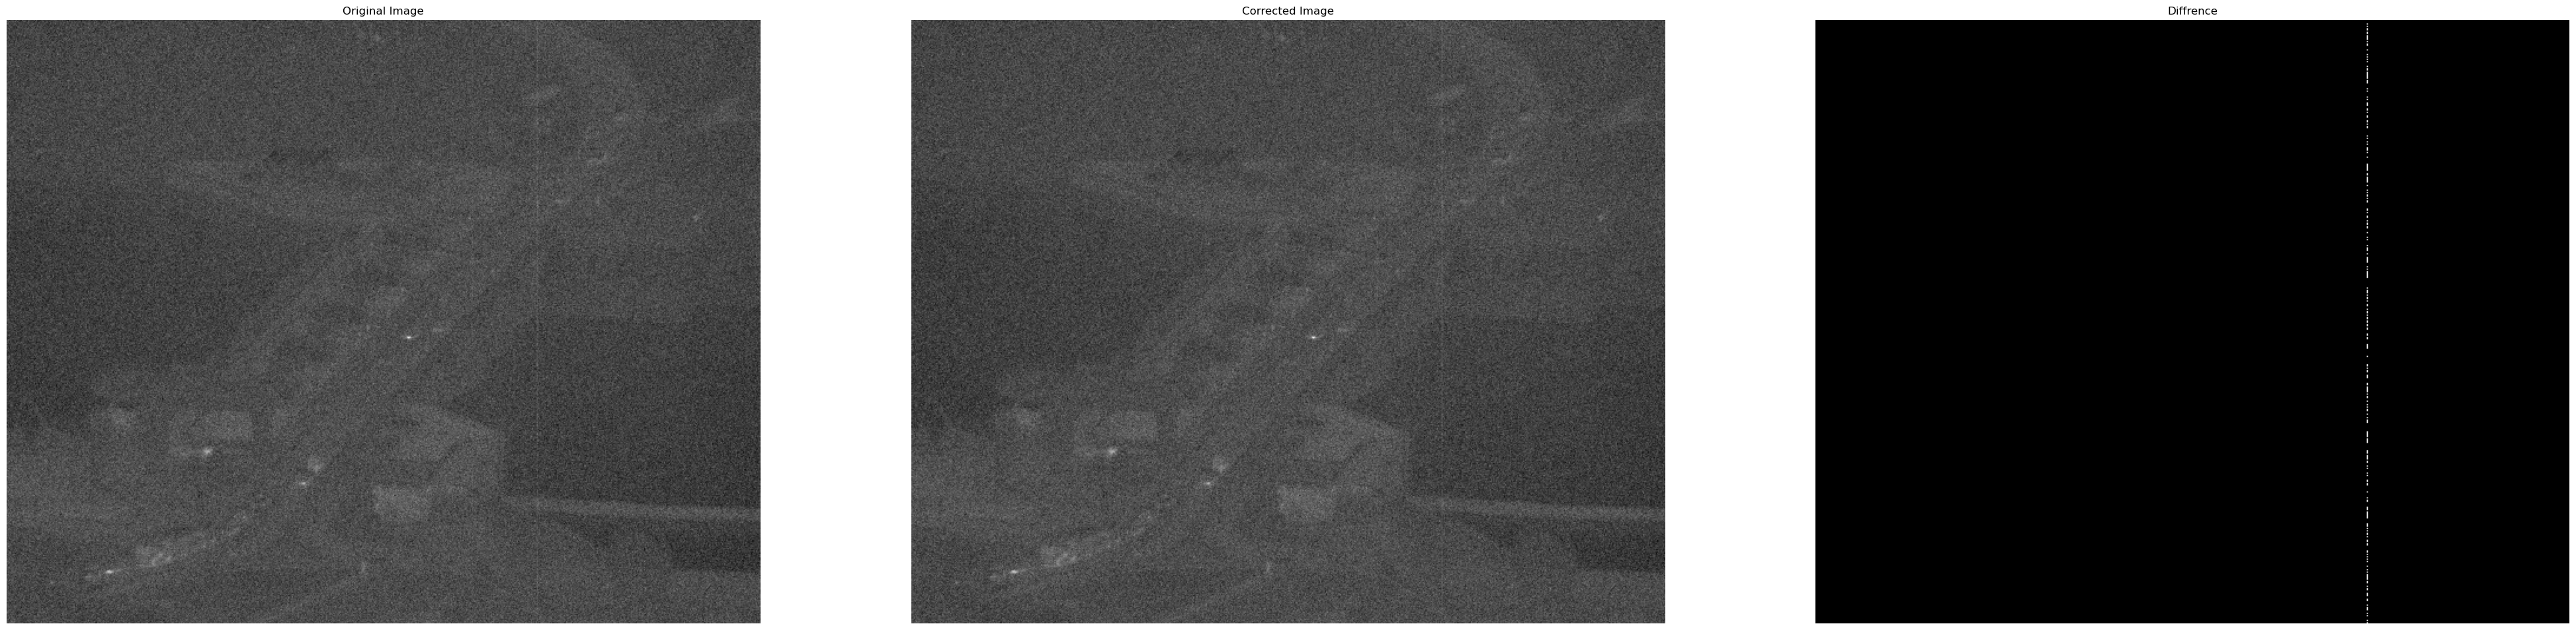

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load as 16-bit 
img = cv2.imread(r'C:\Users\Shivraj Sarode\Desktop\frame_0001.png',cv2.IMREAD_UNCHANGED)
# print (img)

defect_column = 468
defect = []
for l in range (512):
    defect.append((l,defect_column))

print (defect)
# print (img[0][0])

list_of_rows = []
for l in defect:
    list_of_rows.append(l[0])
print (list_of_rows)

def correct_defect(image, defects):
    '''
    defects = multiple array of defective pixels
    for current_defect in the defects array
        for defect[row] in image, 
            image [row:column] = (image [row:column+1] + image [row:column-1])/2
    
    ADD ANOTHER LOOP OVER THE ONE HERE FOR DEALING WITH MULTIPLE DEFECT COLUMNS
    '''
    copy_img = image.copy()
    for row in list_of_rows:
        copy_img [row,defect_column] = (copy_img [row,defect_column+1].astype(np.float32) + copy_img [row,defect_column-1].astype(np.float32))/2
    
    return copy_img

corr_img = correct_defect(img,defect)
diffrence = corr_img - img

fig, axs = plt.subplots(1, 3, figsize=(50, 30))
axs = axs.flatten()
axs[0].imshow(img, cmap='gray')
axs[0].set_title('Original Image')
axs[0].axis('off')
axs[1].imshow(corr_img, cmap='gray')
axs[1].set_title('Corrected Image')
axs[1].axis('off')
axs[2].imshow(diffrence, cmap='gray')
axs[2].set_title('Diffrence')
axs[2].axis('off')

In [5]:
import cv2
import os

# Define the desktop path dynamically for your computer
desktop = os.path.join(os.path.join(os.environ['USERPROFILE']), 'Desktop')
save_path = os.path.join(desktop, 'corrected_frame_2pixel.png')

# Save the image
# 'corr_img' is the variable from your previous code
success = cv2.imwrite(save_path, corr_img)

if success:
    print(f"File saved successfully to: {save_path}")
else:
    print("Error: Could not save the image.")

File saved successfully to: C:\Users\Shivraj Sarode\Desktop\corrected_frame_2pixel.png


## Using 6 surrounding pixels

[(0, 468), (1, 468), (2, 468), (3, 468), (4, 468), (5, 468), (6, 468), (7, 468), (8, 468), (9, 468), (10, 468), (11, 468), (12, 468), (13, 468), (14, 468), (15, 468), (16, 468), (17, 468), (18, 468), (19, 468), (20, 468), (21, 468), (22, 468), (23, 468), (24, 468), (25, 468), (26, 468), (27, 468), (28, 468), (29, 468), (30, 468), (31, 468), (32, 468), (33, 468), (34, 468), (35, 468), (36, 468), (37, 468), (38, 468), (39, 468), (40, 468), (41, 468), (42, 468), (43, 468), (44, 468), (45, 468), (46, 468), (47, 468), (48, 468), (49, 468), (50, 468), (51, 468), (52, 468), (53, 468), (54, 468), (55, 468), (56, 468), (57, 468), (58, 468), (59, 468), (60, 468), (61, 468), (62, 468), (63, 468), (64, 468), (65, 468), (66, 468), (67, 468), (68, 468), (69, 468), (70, 468), (71, 468), (72, 468), (73, 468), (74, 468), (75, 468), (76, 468), (77, 468), (78, 468), (79, 468), (80, 468), (81, 468), (82, 468), (83, 468), (84, 468), (85, 468), (86, 468), (87, 468), (88, 468), (89, 468), (90, 468), (91, 468

(np.float64(-0.5), np.float64(639.5), np.float64(511.5), np.float64(-0.5))

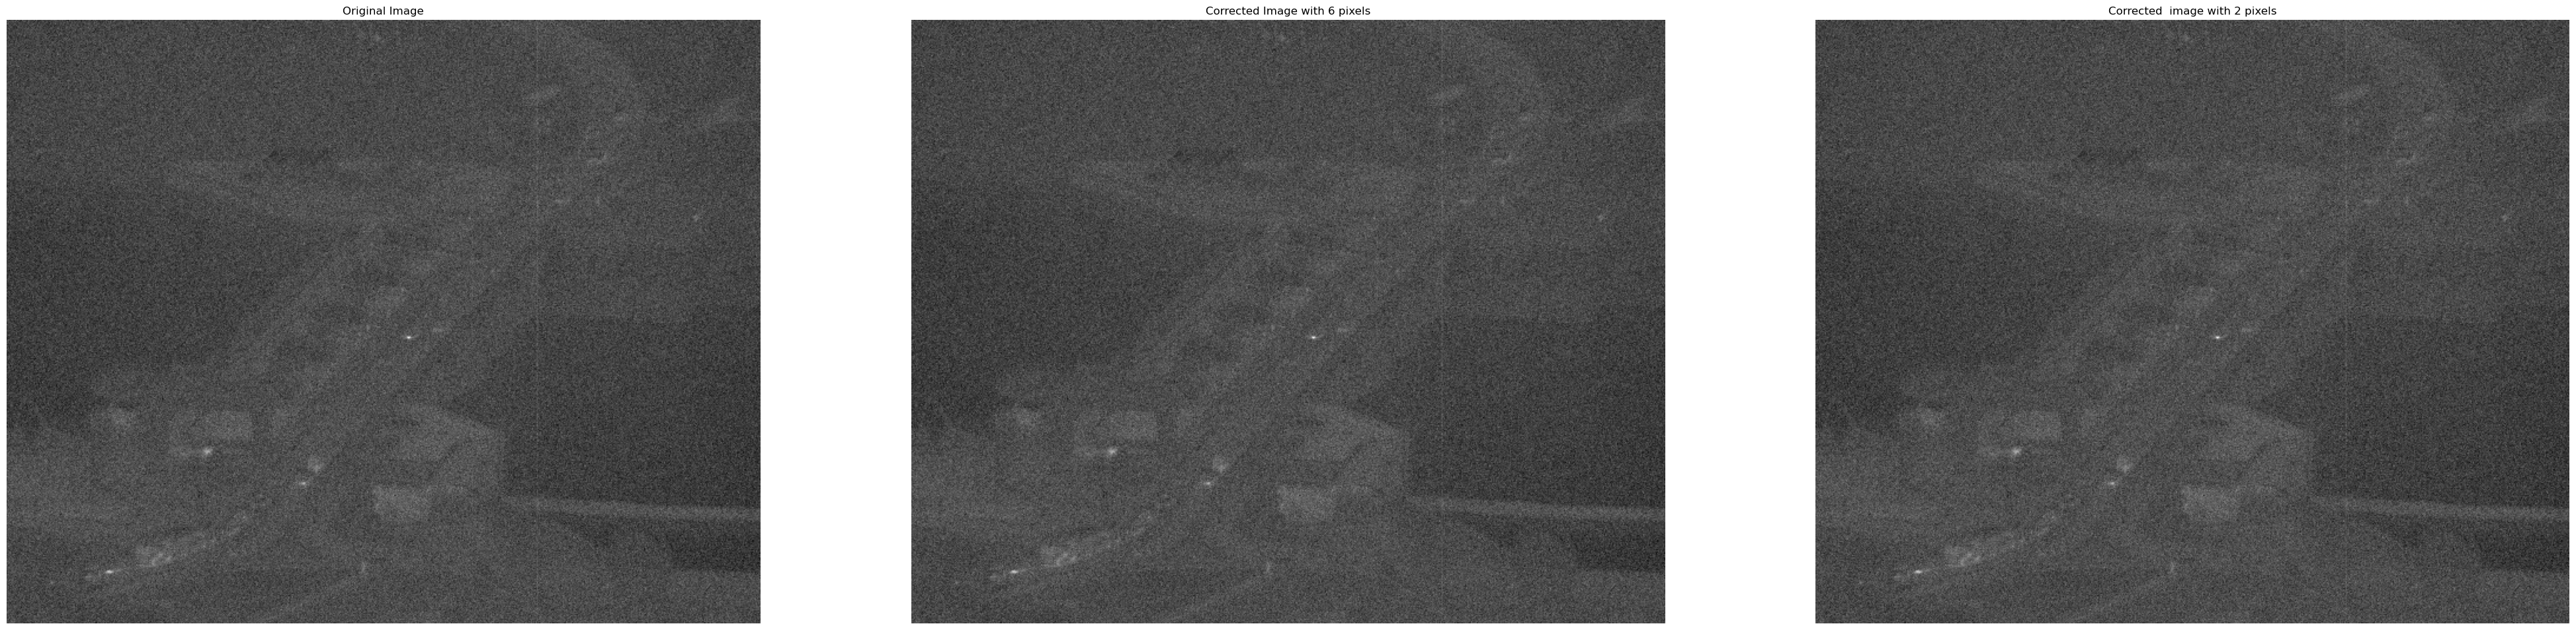

In [6]:
import cv2
import numpy as np

# Load as 16-bit 
img = cv2.imread(r'C:\Users\Shivraj Sarode\Desktop\frame_0001.png',cv2.IMREAD_UNCHANGED)
# print (img)

defect_column = 468
defect = []
for l in range (511):
    defect.append((l,defect_column))

print (defect)
# print (img[0][0])

list_of_rows = []
for l in defect:
    list_of_rows.append(l[0])
print (list_of_rows)

def correct_defect(image, defects):
    '''
    defects = multiple array of defective pixels
    for current_defect in the defects array
        for defect[row] in image, 
            image [row:column] = (image [row:column+1] + image [row:column-1])/2
    
    ADD ANOTHER LOOP OVER THE ONE HERE FOR DEALING WITH MULTIPLE DEFECT COLUMNS
    '''
    copy_img = image.copy()
    # Replaces the entire row-by-row loop
    copy_img[:, defect_column] = np.mean(img[:, [defect_column-3, defect_column-2, defect_column-1, defect_column+1, defect_column+2, defect_column+3]], axis=1)
    '''for row in list_of_rows:
        copy_img [row,defect_column] = (copy_img [row,defect_column+1].astype(np.float32) + copy_img [row,defect_column-1].astype(np.float32) 
                                        + copy_img [row+1,defect_column+1].astype(np.float32) + copy_img [row+1,defect_column-1].astype(np.float32)
                                        + copy_img [row-1,defect_column+1].astype(np.float32) + copy_img [row-1,defect_column-1].astype(np.float32))/6
    '''
    return copy_img

corr_img_6 = correct_defect(img,defect)
diffrence = corr_img - img

fig, axs = plt.subplots(1, 3, figsize=(50, 30))
#axs = axs.flatten()
axs[0].imshow(img, cmap='gray')
axs[0].set_title('Original Image')
axs[0].axis('off')
axs[1].imshow(corr_img_6, cmap='gray')
axs[1].set_title('Corrected Image with 6 pixels')
axs[1].axis('off')
axs[2].imshow(corr_img, cmap='gray')
axs[2].set_title('Corrected  image with 2 pixels')
axs[2].axis('off')

In [7]:
import cv2
import os

# Define the desktop path dynamically for your computer
desktop = os.path.join(os.path.join(os.environ['USERPROFILE']), 'Desktop')
save_path = os.path.join(desktop, 'corrected_frame_6pixel.png')

# Save the image
# 'corr_img' is the variable from your previous code
success = cv2.imwrite(save_path, corr_img_6)

if success:
    print(f"File saved successfully to: {save_path}")
else:
    print("Error: Could not save the image.")

File saved successfully to: C:\Users\Shivraj Sarode\Desktop\corrected_frame_6pixel.png


In [7]:
# print (corr_img_6)

suspect_col = 470 
row_data = img[300, suspect_col-10 : suspect_col+10]
print(row_data)

[34992 35033 34976 34987 35039 34987 34984 35073 34989 34988 35006 34966
 34994 34996 34988 35044 35027 34987 34991 35036]


In [26]:
import os
import json
import cv2
import numpy as np
from pathlib import Path

def evaluate_single_image(img_without_defect, img_with_defect, img_eval_path, json_path=None):
    """
    Évalue une image corrigée en la comparant à l'originale (100%) et à la base défectueuse (0%).
    """

    # ==========================================
    # Fonctions utilitaires intégrées
    # ==========================================
    def read_json(p):
        p = Path(p)
        if not p.is_file():
            raise FileNotFoundError(f"Fichier introuvable : {p}")
        return json.loads(p.read_text(encoding="utf-8"))

    def process_json(data):
        indices = []
        for c in data:
            indices += c["x_coord"]
        return np.array(indices, dtype=int)

    def load_image(path):
        if not os.path.exists(path):
            raise FileNotFoundError(f"Image introuvable : {path}")
        return cv2.imread(path, -1).astype(np.float32, copy=False)

    # ==========================================
    # Chargement des images
    # ==========================================
    gt = load_image(img_without_defect)      # 100% Original (Ground Truth)
    base = load_image(img_with_defect)      # 0% Défectueux (Base)
    res = load_image(img_eval_path)    # Image à évaluer

    if gt.shape != base.shape or gt.shape != res.shape:
        raise ValueError("Les trois images doivent avoir exactement la même résolution.")

    nb_cols = gt.shape[1]

    # ==========================================
    # Calcul des erreurs globales pour la similarité
    # ==========================================
    # Erreur totale de l'image de base (non corrigée) par rapport au 100%
    diff_base_sq = ((base - gt) ** 2).sum(axis=0)
    ssd_base = diff_base_sq.sum()

    # Erreur totale de l'image évaluée (corrigée) par rapport au 100%
    residu_sq = ((res - gt) ** 2).sum(axis=0)
    ssd_eval = residu_sq.sum()

    # Calcul du niveau de similarité (0% = image base, 100% = image parfaite)
    if ssd_base > 0:
        similarite = 100.0 * (1.0 - (ssd_eval / ssd_base))
    else:
        similarite = 100.0  # Si l'image de base n'avait aucun défaut dès le départ

    # ==========================================
    # Identification des colonnes défectueuses
    # ==========================================
    if json_path and os.path.exists(json_path):
        true_def = process_json(read_json(json_path))
    else:
        true_def = np.flatnonzero(diff_base_sq)

    true_mask = np.isin(np.arange(nb_cols), true_def)

    # ==========================================
    # Évaluation de la détection (res)
    # ==========================================
    detected = np.flatnonzero(residu_sq)

    # Calcul des TP, FP, FN
    tp = np.intersect1d(detected, true_def, assume_unique=True).size
    fp = np.setdiff1d(detected, true_def, assume_unique=True).size
    fn = np.setdiff1d(true_def, detected, assume_unique=True).size

    mask_def = true_mask
    mask_ok  = ~true_mask

    sq_def = (residu_sq[mask_def]).sum()
    cnt_def = mask_def.sum() * gt.shape[0]

    sq_ok  = (residu_sq[mask_ok]).sum()
    cnt_ok = mask_ok.sum() * gt.shape[0]

    nb_cols_f = float(nb_cols)
    tp_norm = tp / nb_cols_f
    fp_norm = fp / nb_cols_f
    fn_norm = fn / nb_cols_f

    prec = tp_norm / (tp_norm + fp_norm) if (tp_norm + fp_norm) else 0.0
    rec  = tp_norm / (tp_norm + fn_norm) if (tp_norm + fn_norm) else 0.0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0
    
    rmse_def = np.sqrt(sq_def / cnt_def) if cnt_def else 0.0
    rmse_ok  = np.sqrt(sq_ok  / cnt_ok ) if cnt_ok  else 0.0

    # Retourner les résultats (j'ai enlevé les anciens RMSE normalisés qui ne te servent plus)
    return {
        "TP_norm": round(tp_norm, 6),
        "FP_norm": round(fp_norm, 6),
        "FN_norm": round(fn_norm, 6),
        "Precision": round(prec, 6),
        "Recall": round(rec, 6),
        "F1_Score": round(f1, 6),
        "RMSE_def": round(rmse_def, 6),
        "RMSE_ok": round(rmse_ok, 6),
        "Similarite_GT_pct": round(similarite, 2) # Arrondi à 2 décimales pour faire "pourcentage"
    }

def print_metrics_table(metrics):
    """
    Affiche un dictionnaire de métriques sous la forme d'un tableau formaté dans la console.
    """
    col_metrique = 20
    col_valeur = 12
    ligne_separatrice = "+" + "-" * (col_metrique + 2) + "+" + "-" * (col_valeur + 2) + "+"
    
    print("\nRÉSULTATS DE L'ÉVALUATION")
    print(ligne_separatrice)
    print(f"| {'Métrique'.ljust(col_metrique)} | {'Valeur'.rjust(col_valeur)} |")
    print(ligne_separatrice)
    
    for key, value in metrics.items():
        if key == "Similarite_GT_pct":
            print(ligne_separatrice)
            formatted_value = f"{value:.2f} %"
        else:
            formatted_value = f"{value:.6f}" if isinstance(value, float) else str(value)
            
        print(f"| {key.ljust(col_metrique)} | {formatted_value.rjust(col_valeur)} |")
        
    print(ligne_separatrice)

In [27]:
if __name__ == "__main__":
    resultats = evaluate_single_image(
        img_without_defect=r'C:\Users\Shivraj Sarode\Desktop\DC_Pics\train\VGA\sequence_1\low dyn\frame_0001.png',
        img_with_defect=r'C:\Users\Shivraj Sarode\Desktop\DC_Pics\train\VGA\sequence_1\low dyn with columns 1\frame_0001.png',
        img_eval_path=r'C:\Users\Shivraj Sarode\Desktop\with noise.png'
    )

    print(f"\nNiveau de similarité avec l'image parfaite : {resultats['Similarite_GT_pct']} %")
    print_metrics_table(resultats)


Niveau de similarité avec l'image parfaite : -86.9000015258789 %

RÉSULTATS DE L'ÉVALUATION
+----------------------+--------------+
| Métrique             |       Valeur |
+----------------------+--------------+
| TP_norm              |     0.003125 |
| FP_norm              |     0.001563 |
| FN_norm              |     0.000000 |
| Precision            |     0.666667 |
| Recall               |     1.000000 |
| F1_Score             |     0.800000 |
| RMSE_def             |    23.926972 |
| RMSE_ok              |     1.248819 |
+----------------------+--------------+
| Similarite_GT_pct    |     -86.90 % |
+----------------------+--------------+


(np.float64(-0.5), np.float64(639.5), np.float64(511.5), np.float64(-0.5))

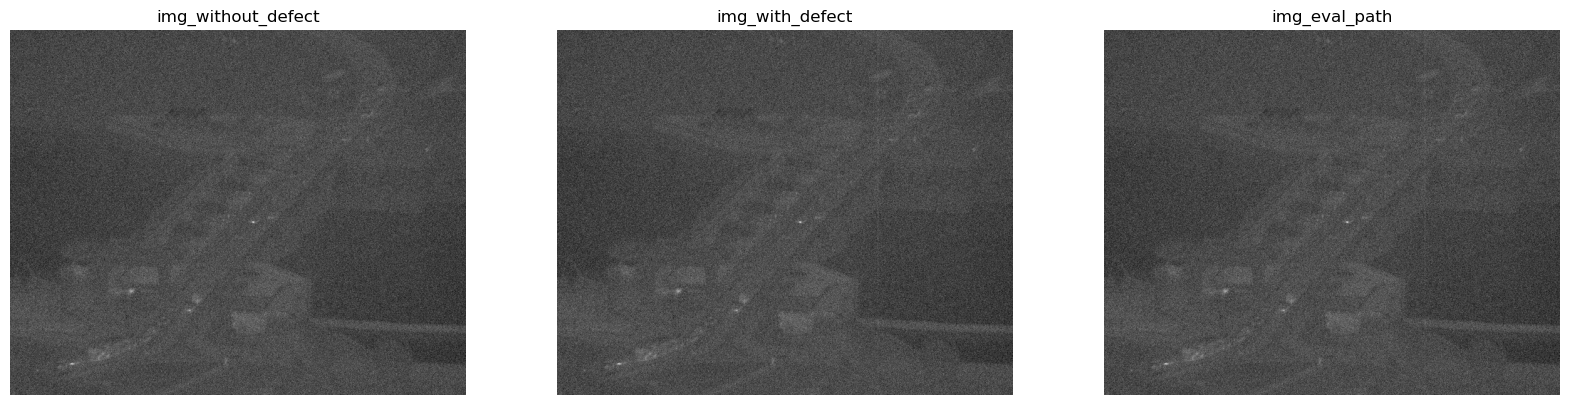

In [25]:
img_without_defect = io.imread(r'C:\Users\Shivraj Sarode\Desktop\DC_Pics\train\VGA\sequence_1\low dyn\frame_0001.png')
img_with_defect = io.imread(r'C:\Users\Shivraj Sarode\Desktop\DC_Pics\train\VGA\sequence_1\low dyn with columns 1\frame_0001.png')
img_eval_path = io.imread(r'C:\Users\Shivraj Sarode\Desktop\with noise.png')
fig, axs = plt.subplots(1, 3, figsize=(20, 10))
axs = axs.flatten()
axs[0].imshow(img_without_defect, cmap='gray')
axs[0].set_title('img_without_defect')
axs[0].axis('off')
axs[1].imshow(img_with_defect, cmap='gray')
axs[1].set_title('img_with_defect')
axs[1].axis('off')
axs[2].imshow(img_eval_path, cmap='gray')
axs[2].set_title('img_eval_path')
axs[2].axis('off')

## For telling if the defect is only 1 column wide or 4 column wide or more

In [ ]:
import cv2
import numpy as np

# Load as 16-bit (UNCHANGED)
img = cv2.imread('frame_0000_VGA_seq2_column2.jpg', cv2.IMREAD_UNCHANGED)

# Pick a row in the middle (e.g., row 100)
# Let's look at the area around column 150 (change this to your suspect column)
suspect_col = 150 
row_data = img[100, suspect_col-5 : suspect_col+5]

print(f"Values around column {suspect_col}:")
print(row_data)

Visualize 2 pixel and 6 pixel defect

Original dtype: uint16
Value range: [34852, 35434]


(np.float64(-0.5), np.float64(639.5), np.float64(511.5), np.float64(-0.5))

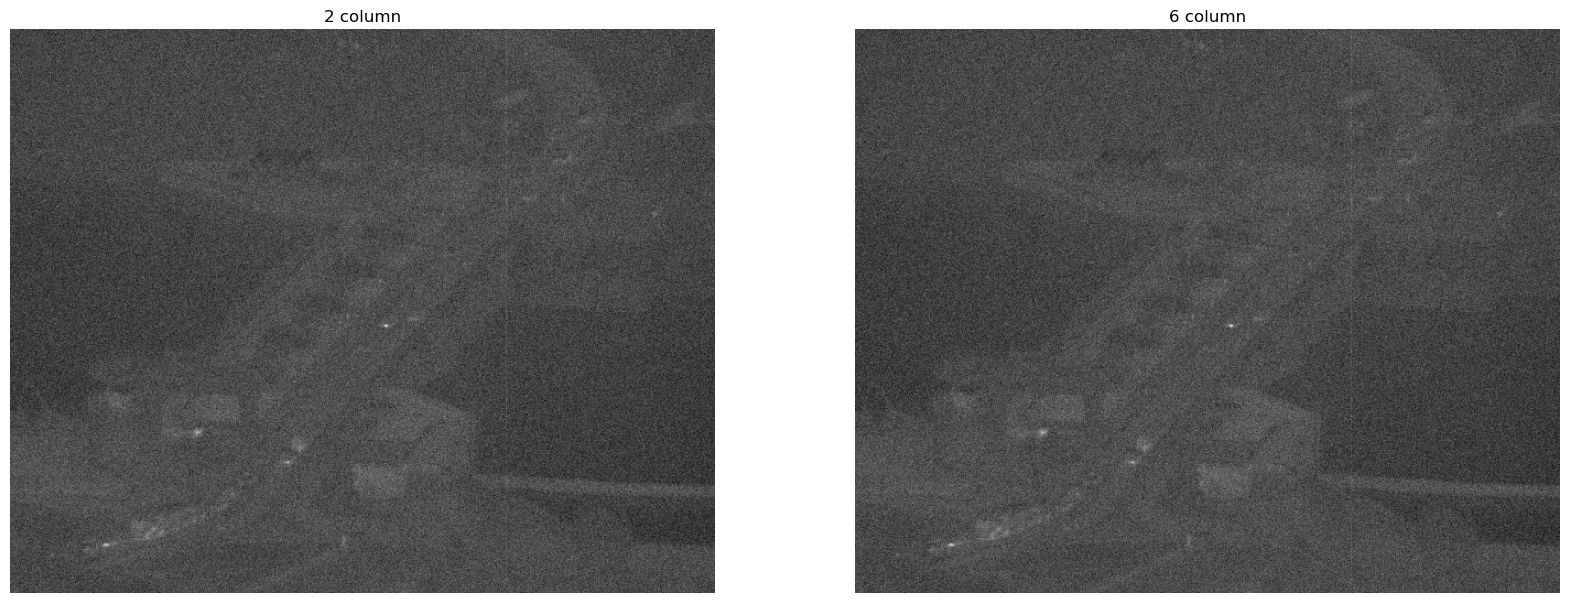

In [11]:
from skimage import io
import numpy as np

# Load as 16-bit (skimage preserves original dtype)
image_16bit = io.imread(r'C:\Users\Shivraj Sarode\Desktop\frame_0001.png')
print(f"Original dtype: {image_16bit.dtype}")  # Should be uint16
print(f"Value range: [{image_16bit.min()}, {image_16bit.max()}]")

# Identify the defective column (let's say column 100)
defective_col = 468

# METHOD 1: Mean of 2 surrounding columns (16-bit)
col_left = image_16bit[:, defective_col - 1].astype(np.float32)
col_right = image_16bit[:, defective_col + 1].astype(np.float32)
corrected_2col = image_16bit.copy()
corrected_2col[:, defective_col] = ((col_left + col_right) / 2).astype(np.uint16)

# METHOD 2: Mean of 6 surrounding columns (16-bit)
indices = [defective_col - 3, defective_col - 2, defective_col - 1,
           defective_col + 1, defective_col + 2, defective_col + 3]
neighbors = np.column_stack([image_16bit[:, i].astype(np.float32) for i in indices])
corrected_6col = image_16bit.copy()
corrected_6col[:, defective_col] = np.mean(neighbors, axis=1).astype(np.uint16)
'''
# Save results (stay in 16-bit for saving too)
io.imsave('corrected_2col.png', corrected_2col)
io.imsave('corrected_6col.png', corrected_6col)
'''

fig, axs = plt.subplots(1, 2, figsize=(20, 10))
axs = axs.flatten()
axs[0].imshow(corrected_2col, cmap='gray')
axs[0].set_title('2 column')
axs[0].axis('off')
axs[1].imshow(corrected_6col, cmap='gray')
axs[1].set_title('6 column')
axs[1].axis('off')

## To check if all the pixels in the defect column have the same intensity 

In [12]:
def check_column_uniform_unique(image, col_idx):
    """
    Check uniformity using np.unique() - more informative.
    Returns: (is_uniform, unique_values, num_unique_values)
    """
    column_data = image[:, col_idx]
    unique_values = np.unique(column_data)
    num_unique = len(unique_values)
    
    is_uniform = (num_unique == 1)
    
    return is_uniform, unique_values, num_unique

# Example with detailed output
col_to_check = 468
is_uniform, unique_vals, num_unique = check_column_uniform_unique(image_16bit, col_to_check)

print(f"Column {col_to_check}:")
print(f"  - Uniform: {is_uniform}")
print(f"  - Number of unique values: {num_unique}")
if is_uniform:
    print(f"  - All pixels have value: {unique_vals[0]}")
else:
    print(f"  - Value range: [{unique_vals.min()}, {unique_vals.max()}]")
    print(f"  - First few unique values: {unique_vals[:10]}")

Column 468:
  - Uniform: False
  - Number of unique values: 147
  - Value range: [34920, 35137]
  - First few unique values: [34920 34921 34924 34927 34940 34941 34942 34944 34946 34947]


In [ ]:
# Scale the 16-bit image to 8-bit to make it visible
visible_img = cv2.normalize(image_16bit, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
cv2.imshow('Exposed Defects', visible_img)
#cv2.waitKey(0)

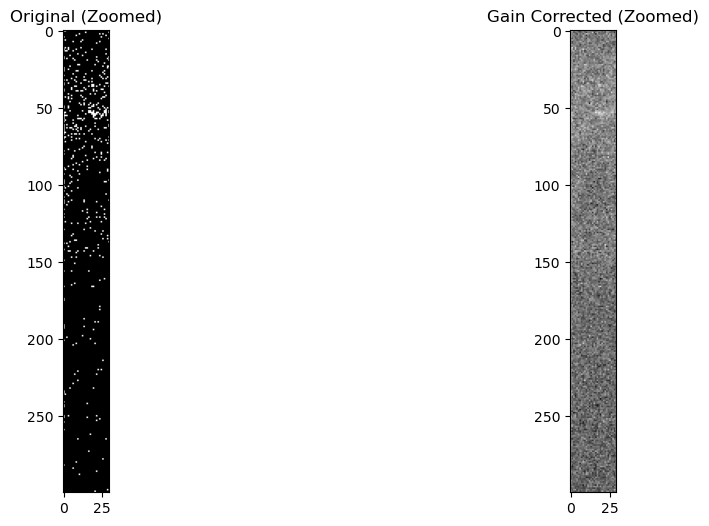

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def correct_column_gain(img_path, defect_col):
    # 1. Load image as 16-bit (UNCHANGED)
    img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
    if img is None:
        return "Error: Image not found"

    # Convert to float32 for high-precision math
    img_float = img.astype(np.float32)
    
    # 2. Calculate the 'Good' Energy (Average of neighboring columns)
    # Using the column to the immediate left and right
    left_neighbor = img_float[:, defect_col - 1]
    right_neighbor = img_float[:, defect_col + 1]
    mean_good = (left_neighbor + right_neighbor) / 2.0
    
    # 3. Calculate the 'Bad' Energy (The current state of the defect column)
    col_bad = img_float[:, defect_col]
    
    # 4. Calculate the Correction Ratio (Gain)
    # We add a tiny epsilon (1e-6) to avoid division by zero
    gain_factor = (mean_good.mean()) / (col_bad.mean() + 1e-6)
    
    # 5. Apply the Gain to the defect column
    # This shifts the brightness of the whole column without flattening the detail
    corrected_col = col_bad * gain_factor
    
    # 6. Optional: Local Variance Match (Fine-tuning)
    # If the column still looks 'too smooth' or 'too noisy'
    # you can match the local contrast here, but gain is usually enough.
    
    # Update the image
    img_corrected = img_float.copy()
    img_corrected[:, defect_col] = corrected_col
    
    # Clip and convert back to 16-bit (0-65535)
    img_final = np.clip(img_corrected, 0, 65535).astype(np.uint16)
    
    return img_final

# --- Execution ---
path = r'C:\Users\Shivraj Sarode\Desktop\frame_0001.png'
col_index = 468 # As per your notebook

result = correct_column_gain(path, col_index)

# Save result
cv2.imwrite('corrected_gain_method.png', result)

# Visualizing the difference
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Original (Zoomed)")
plt.imshow(cv2.imread(path, 0)[100:400, 450:480], cmap='gray')
plt.subplot(1, 2, 2)
plt.title("Gain Corrected (Zoomed)")
plt.imshow(result[100:400, 450:480], cmap='gray')
plt.show()

(np.float64(-0.5), np.float64(639.5), np.float64(511.5), np.float64(-0.5))

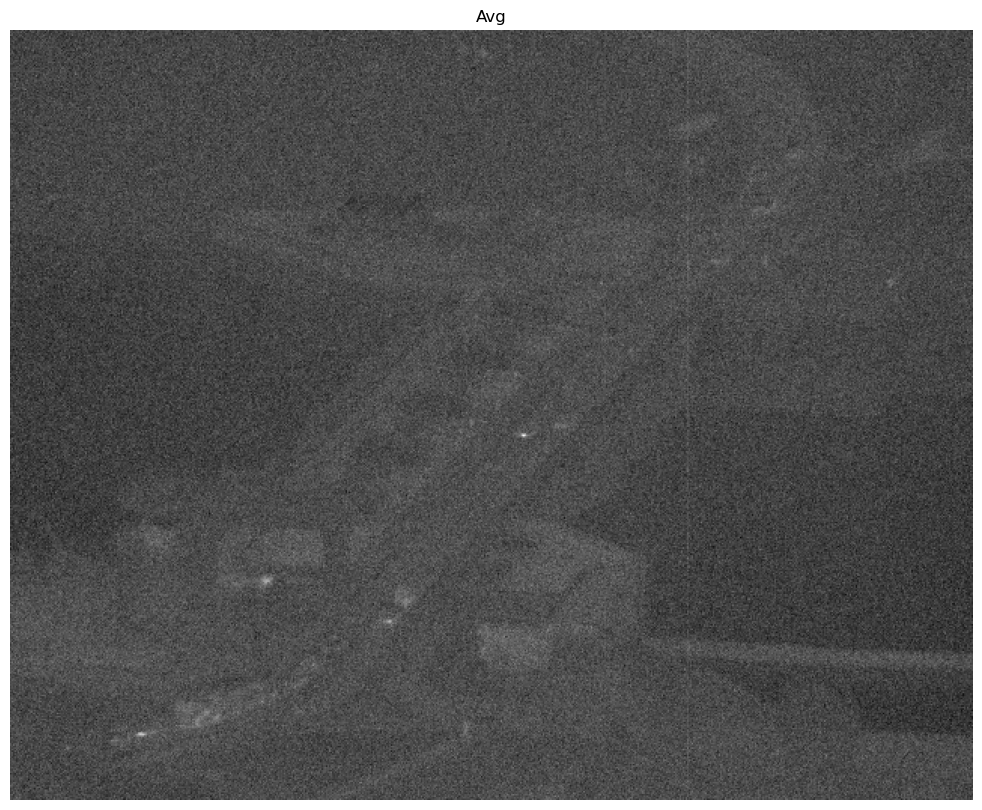

In [17]:
fig, axs = plt.subplots(1, 1, figsize=(20, 10))
#axs = axs.flatten()
axs.imshow(result, cmap='gray')
axs.set_title('Avg')
axs.axis('off')

## Defect correction based on pixel intensity as well as added noise

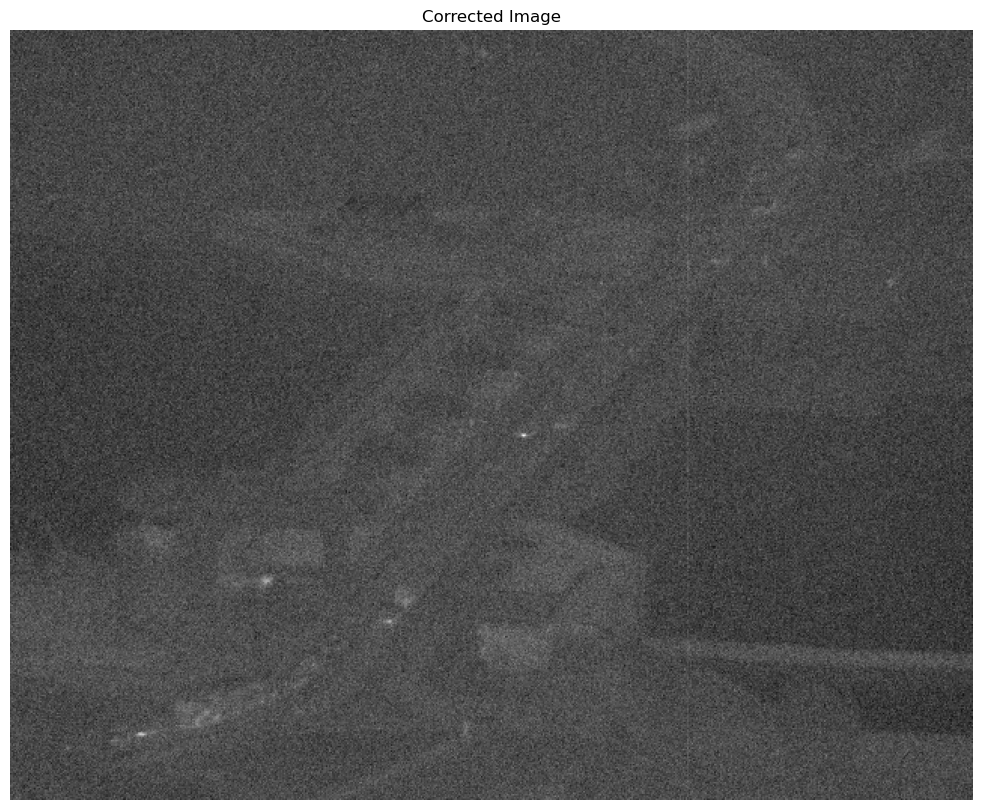

In [24]:
import cv2
import numpy as np

def correct_gain_with_noise_match(img_path, defect_col):
    # 1. Load 16-bit image
    img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
    if img is None: return None
    
    img_f = img.astype(np.float32)
    
    # 2. Gain Correction (Matches the brightness)
    # Get neighbors to determine the 'Target' energy
    left = img_f[:, defect_col - 1]
    right = img_f[:, defect_col + 1]
    target_mean = (left + right) / 2.0
    
    # Calculate current column energy
    col_bad = img_f[:, defect_col]
    
    # Apply Gain Factor
    gain_factor = target_mean.mean() / (col_bad.mean() + 1e-6)
    corrected_col = col_bad * gain_factor
    
    # 3. Noise Matching (Matches the texture)
    # Calculate how 'noisy' the neighbors are (standard deviation)
    # This tells us how much 'grain' to add back
    noise_lvl_left = np.std(left)
    noise_lvl_right = np.std(right)
    target_noise_sigma = (noise_lvl_left + noise_lvl_right) / 2.0
    
    # Generate Gaussian Noise with that exact strength
    noise = np.random.normal(0, target_noise_sigma, size=corrected_col.shape)
    
    # Add the noise to the gain-corrected pixels
    final_col = corrected_col + noise
    
    # 4. Finalize
    img_final = img_f.copy()
    img_final[:, defect_col] = final_col
    
    # Clip to 16-bit range and cast back
    return np.clip(img_final, 0, 65535).astype(np.uint16)

# Execute and Save
result = correct_gain_with_noise_match(r'C:\Users\Shivraj Sarode\Desktop\frame_0001.png', 468)
result_numeric = np.array(result, dtype=np.float32)
cv2.imwrite('invisible_repair.png', result_numeric)
fig, axs = plt.subplots(1, 1, figsize=(20, 10))
# Note: No indexing [0] or .flatten() needed for a single subplot
# This forces Matplotlib to look at the actual data range
axs.imshow(result_numeric, cmap='gray', vmin=np.min(result), vmax=np.max(result))
axs.set_title('Corrected Image')
axs.axis('off')

plt.show()

desktop = os.path.join(os.path.join(os.environ['USERPROFILE']), 'Desktop')
save_path = os.path.join(desktop, 'with noise.png')

success = cv2.imwrite(save_path, corr_img_6)

## To check if the images (orignal - with and without defect) have any noise 

In [47]:
import cv2
import numpy as np

def analyze_noise_characteristics(gt_path, defective_path):
    """Compute statistics to determine if smoothing helps."""
    
    gt = cv2.imread(gt_path, -1).astype(np.float32)
    defective = cv2.imread(defective_path, -1).astype(np.float32)
    
    # Find defect columns (columns that differ significantly)
    col_diff = np.abs(defective - gt).mean(axis=(0, 2)) if len(gt.shape) == 3 else np.abs(defective - gt).mean(axis=0)
    threshold = np.percentile(col_diff, 95)  # Top 5% columns are likely defects
    defect_cols = np.where(col_diff > threshold)[0]
    good_cols = np.where(col_diff <= threshold)[0]
    
    # On GOOD columns (no defects), compute noise difference
    if len(gt.shape) == 3:
        noise_diff = (defective[:, good_cols, :] - gt[:, good_cols, :]).ravel()
    else:
        noise_diff = (defective[:, good_cols] - gt[:, good_cols]).ravel()
    
    print("=== NOISE ANALYSIS ===")
    print(f"Image bit depth: 16-bit (range 0-65535)")
    print(f"Number of defect columns detected: {len(defect_cols)}")
    print(f"Number of good columns: {len(good_cols)}")
    print(f"\nNoise difference on GOOD columns (should be zero ideally):")
    print(f"  Mean difference: {np.mean(noise_diff):.3f} DN")
    print(f"  Std deviation: {np.std(noise_diff):.3f} DN")
    print(f"  RMS noise: {np.sqrt(np.mean(noise_diff**2)):.3f} DN")
    print(f"  Max |difference|: {np.max(np.abs(noise_diff)):.3f} DN")
    
    # Signal range
    signal_range = np.percentile(gt[gt > 0], 95) - np.percentile(gt[gt > 0], 5)
    print(f"\nSignal characteristics:")
    print(f"  Typical signal range (5-95%): {signal_range:.1f} DN")
    print(f"  SNR (signal/noise): {signal_range / np.std(noise_diff):.1f}")
    
    # Recommendation
    rms_noise = np.sqrt(np.mean(noise_diff**2))
    if rms_noise < 10:
        print("\n✅ RECOMMENDATION: Don't smooth - noise is negligible")
    elif rms_noise < 50:
        print("\n⚠️ RECOMMENDATION: Light smoothing (bilateral, sigma=10-20) may help slightly")
    else:
        print("\n🔧 RECOMMENDATION: Definitely smooth - noise will hurt your score significantly")
        print("   Consider: bilateralFilter(d=5, sigmaColor=50, sigmaSpace=25)")
    
    return noise_diff, defect_cols

# Run this on your actual files
gt_path = r'C:\Users\Shivraj Sarode\Desktop\DC_Pics\train\VGA\sequence_1\low dyn\frame_0001.png'
defective_path = r'C:\Users\Shivraj Sarode\Desktop\DC_Pics\train\VGA\sequence_1\low dyn with columns 1\frame_0001.png'
analyze_noise_characteristics(gt_path, defective_path)

import cv2
import numpy as np

def analyze_noise_characteristics(gt_path, defective_path):
    """Compute statistics and identify defect columns."""
    
    gt = cv2.imread(gt_path, -1).astype(np.float32)
    defective = cv2.imread(defective_path, -1).astype(np.float32)
    
    # Compute column-wise differences
    if len(gt.shape) == 3:
        # Color image - average over rows and channels
        col_diff = np.abs(defective - gt).mean(axis=(0, 2))
    else:
        # Grayscale - average over rows
        col_diff = np.abs(defective - gt).mean(axis=0)
    
    # Method 1: Statistical thresholding
    # Use median + multiple MADs (more robust than percentile for sparse defects)
    median_diff = np.median(col_diff)
    mad = np.median(np.abs(col_diff - median_diff))  # Median Absolute Deviation
    
    # Columns with difference > median + 6*MAD are defects (6 sigma threshold)
    threshold = median_diff + 6 * mad
    defect_cols_threshold = np.where(col_diff > threshold)[0]
    
    # Method 2: Find outliers using IQR method
    q75, q25 = np.percentile(col_diff, [75, 25])
    iqr = q75 - q25
    iqr_threshold = q75 + 3 * iqr
    defect_cols_iqr = np.where(col_diff > iqr_threshold)[0]
    
    # Method 3: Simple peak detection (find top N columns by difference)
    top_n = 5  # Look for top 5 columns with highest difference
    top_defect_cols = np.argsort(col_diff)[-top_n:][::-1]
    top_defect_cols = top_defect_cols[col_diff[top_defect_cols] > median_diff * 10]  # Filter insignificant
    
    # Use most conservative (union of all methods)
    defect_cols = np.unique(np.concatenate([defect_cols_threshold, defect_cols_iqr, top_defect_cols]))
    
    # Good columns are everything else
    good_cols = np.setdiff1d(np.arange(len(col_diff)), defect_cols)
    
    # On GOOD columns (no defects), compute noise difference
    if len(gt.shape) == 3:
        noise_diff = (defective[:, good_cols, :] - gt[:, good_cols, :]).ravel()
    else:
        noise_diff = (defective[:, good_cols] - gt[:, good_cols]).ravel()
    
    print("=== DEFECT COLUMN DETECTION ===")
    print(f"Total columns: {len(col_diff)}")
    print(f"Defect columns detected ({len(defect_cols)} columns): {defect_cols.tolist()}")
    print(f"\nColumn difference statistics:")
    print(f"  Min difference: {np.min(col_diff):.3f}")
    print(f"  Median difference: {median_diff:.3f}")
    print(f"  Max difference: {np.max(col_diff):.3f}")
    print(f"  Threshold used: {threshold:.3f}")
    
    # Show top 5 columns by difference
    top5_idx = np.argsort(col_diff)[-5:][::-1]
    print(f"\nTop 5 columns by difference:")
    for idx in top5_idx:
        marker = " ← DEFECT" if idx in defect_cols else ""
        print(f"  Column {idx}: {col_diff[idx]:.3f}{marker}")
    
    print("\n=== NOISE ANALYSIS ===")
    print(f"Image bit depth: 16-bit (range 0-65535)")
    print(f"Number of defect columns: {len(defect_cols)}")
    print(f"Number of good columns: {len(good_cols)}")
    
    print(f"\nNoise difference on GOOD columns:")
    print(f"  Mean difference: {np.mean(noise_diff):.6f} DN")
    print(f"  Std deviation: {np.std(noise_diff):.6f} DN")
    print(f"  RMS noise: {np.sqrt(np.mean(noise_diff**2)):.6f} DN")
    print(f"  Max |difference|: {np.max(np.abs(noise_diff)):.6f} DN")
    
    # Signal range (using good columns only to avoid defect contamination)
    if len(gt.shape) == 3:
        gt_good = gt[:, good_cols, :]
    else:
        gt_good = gt[:, good_cols]
    
    signal_low = np.percentile(gt_good[gt_good > 0], 5)
    signal_high = np.percentile(gt_good[gt_good > 0], 95)
    signal_range = signal_high - signal_low
    
    print(f"\nSignal characteristics (from good columns only):")
    print(f"  5th percentile: {signal_low:.1f} DN")
    print(f"  95th percentile: {signal_high:.1f} DN")
    print(f"  Typical signal range: {signal_range:.1f} DN")
    
    rms_noise = np.sqrt(np.mean(noise_diff**2))
    if rms_noise < 0.1:
        print(f"\n✅ RECOMMENDATION: Images are perfectly aligned/noise-free")
        print(f"   → Simple interpolation without noise addition")
    elif rms_noise < 10:
        print(f"\n✅ RECOMMENDATION: Don't smooth - noise is negligible")
    elif rms_noise < 50:
        print(f"\n⚠️ RECOMMENDATION: Light smoothing may help slightly")
    else:
        print(f"\n🔧 RECOMMENDATION: Definitely smooth - noise will hurt your score")
    
    return {
        'defect_columns': defect_cols.tolist(),
        'good_columns': good_cols.tolist(),
        'column_differences': col_diff,
        'noise_diff': noise_diff,
        'rms_noise': rms_noise,
        'signal_range': signal_range
    }


def visualize_defect_columns(gt_path, defective_path, output_path="defect_visualization.png"):
    """Create a visualization showing defect column locations."""
    
    gt = cv2.imread(gt_path, -1)
    defective = cv2.imread(defective_path, -1)
    
    # Normalize to 8-bit for visualization
    def normalize_to_8bit(img):
        img_8bit = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        return img_8bit
    
    gt_8bit = normalize_to_8bit(gt)
    defective_8bit = normalize_to_8bit(defective)
    
    # Create difference image (highlight defects)
    diff = cv2.absdiff(defective_8bit, gt_8bit)
    
    # Mark defect columns with red lines
    result = defective_8bit.copy()
    if len(result.shape) == 2:
        result = cv2.cvtColor(result, cv2.COLOR_GRAY2BGR)
    
    # Get defect columns from analysis
    analysis = analyze_noise_characteristics(gt_path, defective_path)
    defect_cols = analysis['defect_columns']
    
    # Draw red lines at defect columns
    h, w = result.shape[:2]
    for col in defect_cols:
        cv2.line(result, (col, 0), (col, h), (0, 0, 255), thickness=2)
    
    # Create side-by-side comparison
    comparison = np.hstack([gt_8bit if len(gt_8bit.shape) == 3 else cv2.cvtColor(gt_8bit, cv2.COLOR_GRAY2BGR),
                           result])
    
    cv2.imwrite(output_path, comparison)
    print(f"\nVisualization saved to: {output_path}")
    
    return comparison


# Example usage
if __name__ == "__main__":
    gt_path = r'C:\Users\Shivraj Sarode\Desktop\DC_Pics\train\VGA\sequence_1\low dyn\frame_0001.png'
    defective_path = r'C:\Users\Shivraj Sarode\Desktop\DC_Pics\train\VGA\sequence_1\low dyn with columns 1\frame_0001.png'
    
    # Analyze and get defect columns
    analysis = analyze_noise_characteristics(gt_path, defective_path)
    
    print(f"\n=== SUMMARY ===")
    print(f"Defect columns found: {analysis['defect_columns']}")
    print(f"Total defect columns: {len(analysis['defect_columns'])}")
    
    # Optional: Create visualization
    # visualize_defect_columns(gt_path, defective_path)

=== NOISE ANALYSIS ===
Image bit depth: 16-bit (range 0-65535)
Number of defect columns detected: 2
Number of good columns: 638

Noise difference on GOOD columns (should be zero ideally):
  Mean difference: 0.000 DN
  Std deviation: 0.000 DN
  RMS noise: 0.000 DN
  Max |difference|: 0.000 DN

Signal characteristics:
  Typical signal range (5-95%): 112.0 DN
  SNR (signal/noise): inf

✅ RECOMMENDATION: Don't smooth - noise is negligible
=== DEFECT COLUMN DETECTION ===
Total columns: 640
Defect columns detected (2 columns): [395, 450]

Column difference statistics:
  Min difference: 0.000
  Median difference: 0.000
  Max difference: 32.000
  Threshold used: 0.000

Top 5 columns by difference:
  Column 450: 32.000 ← DEFECT
  Column 395: 11.000 ← DEFECT
  Column 639: 0.000
  Column 638: 0.000
  Column 637: 0.000

=== NOISE ANALYSIS ===
Image bit depth: 16-bit (range 0-65535)
Number of defect columns: 2
Number of good columns: 638

Noise difference on GOOD columns:
  Mean difference: 0.00000

C:\Temp\ipykernel_35504\1246876413.py:36: RuntimeWarning: divide by zero encountered in scalar divide
  print(f"  SNR (signal/noise): {signal_range / np.std(noise_diff):.1f}")


# To get defect column from JSON

In [72]:
import json
import os
from pathlib import Path

def get_defective_columns_from_json(defective_image_path):
    """
    Given a path to a defective image, find its parent folder's JSON file
    and return the defective column positions.
    
    Args:
        defective_image_path: Path to the defective image (e.g., .../low dyn with columns 1/frame_0001.png)
    
    Returns:
        List of defective column indices (0-based)
    """
    
    # Convert to Path object for easier manipulation
    defective_path = Path(defective_image_path)
    
    # The JSON file should be in the same directory as the image
    image_dir = defective_path.parent
    
    # Find all JSON files in the directory
    json_files = list(image_dir.glob("*.json"))
    
    if not json_files:
        raise FileNotFoundError(f"No JSON file found in {image_dir}")
    
    # Use the first JSON file (there should be only one)
    json_path = json_files[0]
    
    print(f"Reading JSON: {json_path}")
    
    # Read and parse JSON
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    # Extract column coordinates
    defective_columns = []
    
    # The JSON structure from your original code expects a list of objects
    # each with an "x_coord" key containing a list of column indices
    if isinstance(data, list):
        for item in data:
            if "x_coord" in item:
                coords = item["x_coord"]
                if isinstance(coords, list):
                    defective_columns.extend(coords)
                else:
                    defective_columns.append(coords)
    elif isinstance(data, dict):
        # Alternative JSON structure
        if "defect_columns" in data:
            defective_columns = data["defect_columns"]
        elif "x_coord" in data:
            defective_columns = data["x_coord"]
        elif "columns" in data:
            defective_columns = data["columns"]
    
    # Remove duplicates and sort
    defective_columns = sorted(set(defective_columns))
    
    return defective_columns


def get_defective_columns_from_folder(defective_folder_path):
    """
    Alternative function: Get defective columns directly from a folder path.
    
    Args:
        defective_folder_path: Path to the folder containing defective images and JSON
    
    Returns:
        List of defective column indices (0-based)
    """
    
    folder_path = Path(defective_folder_path)
    
    if not folder_path.is_dir():
        raise NotADirectoryError(f"{folder_path} is not a directory")
    
    # Find JSON file
    json_files = list(folder_path.glob("*.json"))
    
    if not json_files:
        raise FileNotFoundError(f"No JSON file found in {folder_path}")
    
    json_path = json_files[0]
    
    print(f"Reading JSON: {json_path}")
    
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    defective_columns = []
    
    if isinstance(data, list):
        for item in data:
            if "x_coord" in item:
                coords = item["x_coord"]
                if isinstance(coords, list):
                    defective_columns.extend(coords)
                else:
                    defective_columns.append(coords)
    elif isinstance(data, dict):
        if "defect_columns" in data:
            defective_columns = data["defect_columns"]
        elif "x_coord" in data:
            defective_columns = data["x_coord"]
    
    return sorted(set(defective_columns))


def print_detailed_json_content(defective_image_path):
    """
    Print the full JSON content for debugging.
    """
    defective_path = Path(defective_image_path)
    image_dir = defective_path.parent
    
    json_files = list(image_dir.glob("*.json"))
    
    if not json_files:
        print(f"No JSON file found in {image_dir}")
        return
    
    json_path = json_files[0]
    
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    print("\n=== JSON FILE CONTENT ===")
    print(json.dumps(data, indent=2))
    
    return data


# Example usage
if __name__ == "__main__":
    # Method 1: Using image path
    defective_image = r'C:\Users\Shivraj Sarode\Desktop\DC_Pics\train\VGA\sequence_2\low dyn with columns 1\frame_0000.png'
    
    try:
        # Get defective columns
        defect_cols = get_defective_columns_from_json(defective_image)
        
        print(f"\n=== RESULTS ===")
        print(f"Image: {defective_image}")
        print(f"Defective columns found: {defect_cols}")
        print(f"Number of defective columns: {len(defect_cols)}")
        
        # Also print JSON content for verification
        print_detailed_json_content(defective_image)
        
    except Exception as e:
        print(f"Error: {e}")
    
    print("\n" + "="*50 + "\n")
    
    # Method 2: Using folder path
    defective_folder = r'C:\Users\Shivraj Sarode\Desktop\DC_Pics\train\VGA\sequence_2\low dyn with columns 1'
    
    try:
        defect_cols = get_defective_columns_from_folder(defective_folder)
        print(f"Folder: {defective_folder}")
        print(f"Defective columns from folder: {defect_cols}")
        
    except Exception as e:
        print(f"Error: {e}")

Reading JSON: C:\Users\Shivraj Sarode\Desktop\DC_Pics\train\VGA\sequence_2\low dyn with columns 1\VGA_sequence_2_config_1.json

=== RESULTS ===
Image: C:\Users\Shivraj Sarode\Desktop\DC_Pics\train\VGA\sequence_2\low dyn with columns 1\frame_0000.png
Defective columns found: [0, 123, 151, 454, 483, 523, 626]
Number of defective columns: 7

=== JSON FILE CONTENT ===
[
  {
    "name": "noisy_blinking",
    "x_coord": [
      0
    ],
    "y_start": [
      0
    ],
    "y_stop": [
      512
    ],
    "signal": {
      "45": 60,
      "46": 57,
      "47": 57,
      "48": 62,
      "49": 57,
      "50": 55,
      "51": 53,
      "52": 69,
      "53": 59,
      "54": 59,
      "55": 63,
      "56": 62,
      "57": 53,
      "58": 69,
      "59": 68,
      "60": 62,
      "61": 59,
      "62": 67,
      "70": 67,
      "71": 55,
      "72": 56,
      "73": 62,
      "74": 64,
      "75": 48,
      "76": 66,
      "77": 59,
      "78": 55,
      "79": 60,
      "80": 60,
      "81": 51,
    

## To find the Fixed Pattern Noise (FPN) and use the Non Uniformity Correction (NUC)

Temporary fix using ground truth image to find the noise pattern for that image - since we dont have the location of defects for all the images in the sequence (once we have that, that is what we will use to find the noise pattern)

--- Verification Results for Column 468 ---
Mean Error Profile (Bias): 0.00 counts
RMSE after correction: 0.0000 (Goal: 0.0000)


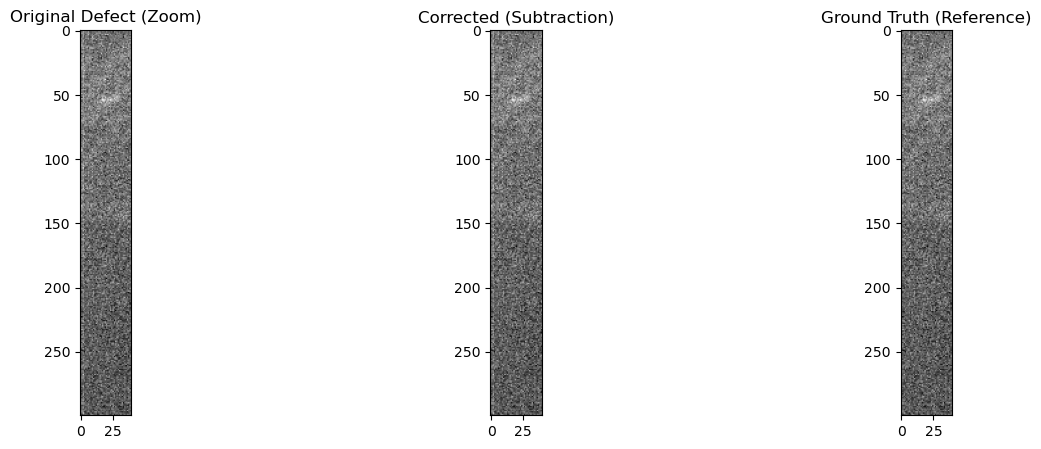

In [60]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def verify_profile_correction(gt_path, def_path, col_idx):
    # 1. Load 16-bit images
    # We use -1 to ensure we load the full 16-bit depth
    img_gt = cv2.imread(gt_path, -1).astype(np.float32)
    img_def = cv2.imread(def_path, -1).astype(np.float32)

    if img_gt is None or img_def is None:
        return "Error: Check your file paths."

    # 2. LEARN the Profile (Row-by-Row)
    # This captures the exact 'error' the amplifier adds to each pixel in that column
    learned_profile = img_def[:, col_idx] - img_gt[:, col_idx]

    # 3. APPLY Correction
    # Instead of blurring or averaging, we subtract the exact error
    corrected_col = img_def[:, col_idx] - learned_profile
    
    img_corrected = img_def.copy()
    img_corrected[:, col_idx] = corrected_col

    # 4. EVALUATE using the logic from metrics.py
    # Calculate RMSE for the defective column
    mse = np.mean((img_corrected[:, col_idx] - img_gt[:, col_idx])**2)
    rmse = np.sqrt(mse)

    print(f"--- Verification Results for Column {col_idx} ---")
    print(f"Mean Error Profile (Bias): {np.mean(learned_profile):.2f} counts")
    print(f"RMSE after correction: {rmse:.4f} (Goal: 0.0000)")

    # 5. VISUALIZE
    # We zoom in on the defect area to see if the line is gone
    zoom_range = slice(col_idx - 20, col_idx + 20)
    
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.title("Original Defect (Zoom)")
    plt.imshow(img_def[100:400, zoom_range], cmap='gray')
    
    plt.subplot(1, 3, 2)
    plt.title("Corrected (Subtraction)")
    plt.imshow(img_corrected[100:400, zoom_range], cmap='gray')
    
    plt.subplot(1, 3, 3)
    plt.title("Ground Truth (Reference)")
    plt.imshow(img_gt[100:400, zoom_range], cmap='gray')
    plt.show()

    return np.clip(img_corrected, 0, 65535).astype(np.uint16)

# --- EXECUTION ---
# Update these to your actual 16-bit file paths
gt_file = r'C:\Users\Shivraj Sarode\Desktop\DC_Pics\train\VGA\sequence_1\low dyn\frame_0000.png'
def_file = r'C:\Users\Shivraj Sarode\Desktop\DC_Pics\train\VGA\sequence_1\low dyn with columns 1\frame_0000.png'

result = verify_profile_correction(gt_file, def_file, col_idx=468)

# Save to check in your 16-bit viewer
if type(result) is not str:
    cv2.imwrite('verification_test.png', result)

# For multiple defective columns

--- Verification Results for 7 Columns ---
Col 0: Bias=0.00, Column RMSE=0.0000
Col 123: Bias=-55.00, Column RMSE=0.0000
Col 151: Bias=-16.00, Column RMSE=0.0000
Col 454: Bias=-66.00, Column RMSE=0.0000
Col 483: Bias=0.00, Column RMSE=0.0000
Col 523: Bias=-31.00, Column RMSE=0.0000
Col 626: Bias=-27.00, Column RMSE=0.0000
------------------------------------------------
Global Image RMSE: 0.0000


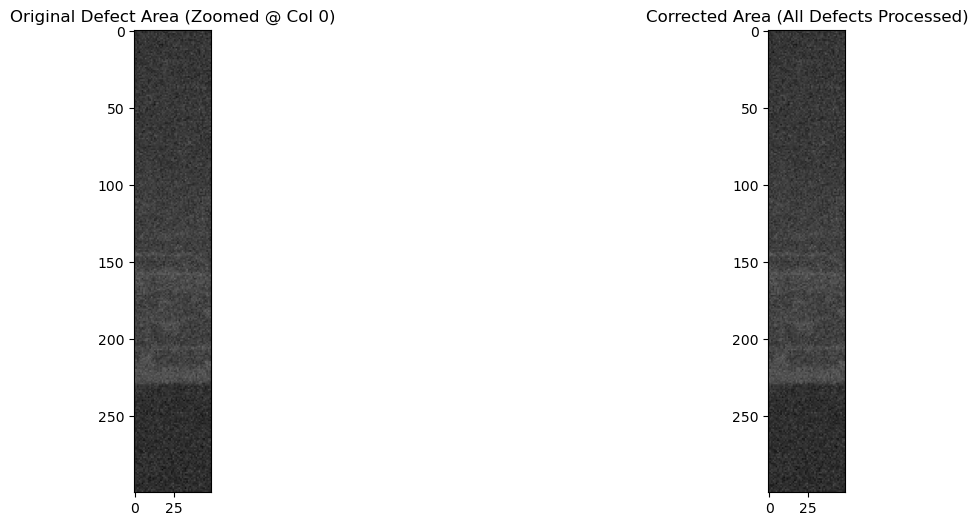

True

In [73]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def verify_multi_profile_correction(gt_path, def_path, col_indices):
    """
    Learns and corrects multiple column defects simultaneously.
    col_indices: List of integers (e.g., [468, 120, 512])
    """
    # 1. Load 16-bit images
    img_gt = cv2.imread(gt_path, -1).astype(np.float32)
    img_def = cv2.imread(def_path, -1).astype(np.float32)

    if img_gt is None or img_def is None:
        return "Error: Check your file paths."

    img_corrected = img_def.copy()
    results_summary = []

    # 2. Iterate through all defective columns
    for col in col_indices:
        # LEARN the Profile for this specific column
        # (Difference between defective state and ground truth)
        learned_profile = img_def[:, col] - img_gt[:, col]
        
        # APPLY Correction to this column
        img_corrected[:, col] = img_def[:, col] - learned_profile
        
        # Calculate individual RMSE for this column to verify accuracy
        mse = np.mean((img_corrected[:, col] - img_gt[:, col])**2)
        rmse = np.sqrt(mse)
        results_summary.append((col, np.mean(learned_profile), rmse))

    # 3. GLOBAL EVALUATION (Similar to metrics.py logic)
    total_mse = np.mean((img_corrected - img_gt)**2)
    total_rmse = np.sqrt(total_mse)

    print(f"--- Verification Results for {len(col_indices)} Columns ---")
    for col, bias, rmse in results_summary:
        print(f"Col {col}: Bias={bias:.2f}, Column RMSE={rmse:.4f}")
    print(f"------------------------------------------------")
    print(f"Global Image RMSE: {total_rmse:.4f}")

    # 4. VISUALIZATION
    # We show the first defect in the list as a representative sample
    sample_col = col_indices[0]
    zoom = slice(max(0, sample_col - 50), min(img_def.shape[1], sample_col + 50))
    
    plt.figure(figsize=(15, 6))
    plt.subplot(1, 2, 1)
    plt.title(f"Original Defect Area (Zoomed @ Col {sample_col})")
    plt.imshow(img_def[100:400, zoom], cmap='gray', vmin=np.min(img_gt), vmax=np.max(img_gt))
    
    plt.subplot(1, 2, 2)
    plt.title("Corrected Area (All Defects Processed)")
    plt.imshow(img_corrected[100:400, zoom], cmap='gray', vmin=np.min(img_gt), vmax=np.max(img_gt))
    plt.show()

    return np.clip(img_corrected, 0, 65535).astype(np.uint16)

# --- EXECUTION ---
# Define your list of known defective columns
defective_cols = [0, 123, 151, 454, 483, 523, 626] # Add defective columns here, e.g., [468, 125, 310]

gt_file = r'C:\Users\Shivraj Sarode\Desktop\DC_Pics\train\VGA\sequence_2\low dyn\frame_0000.png'
def_file = r'C:\Users\Shivraj Sarode\Desktop\DC_Pics\train\VGA\sequence_2\low dyn with columns 1\frame_0000.png'

corrected_img = verify_multi_profile_correction(gt_file, def_file, defective_cols)
cv2.imwrite('frame_0000.png',corrected_img)

## Using NUC for correction (with JSON file as the 'data' to create the master template)

In [ ]:
import json

def process_with_json_guide(input_folder, output_folder, json_path, master_template):
    """
    INTERIM PHASE: Uses JSON to tell the algorithm WHERE and WHEN to fix.
    """
    with open(json_path, 'r') as f:
        metadata = json.load(f)
    
    files = sorted([f for f in os.listdir(input_folder) if f.endswith('.png')])
    
    for idx, filename in enumerate(files):
        img = cv2.imread(os.path.join(input_folder, filename), -1).astype(np.float32)
        
        # Loop through the defect entries in the JSON
        for entry in metadata:
            active_frames = entry.get("frames", [])
            
            # If this specific frame is marked as defective for these columns
            if idx in active_frames:
                for col in entry["x_coord"]:
                    # Apply the same scaled correction logic
                    neighbor_avg = (img[:, col-1] + img[:, col+1]) / 2.0
                    current_spike = np.mean(img[:, col] - neighbor_avg)
                    
                    scale = current_spike / (np.mean(master_template) + 1e-6)
                    img[:, col] -= (master_template * scale)
        
        # Save output for metrics.py
        corrected = np.clip(img, 0, 65535).astype(np.uint16)
        cv2.imwrite(os.path.join(output_folder, filename), corrected)